<a href="https://www.kaggle.com/code/dimaspashaakrilian/knn-model-implementation?scriptVersionId=311136458" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


# Data Cleaning

Import Library

In [2]:
import pandas as pd

Load Dataset

In [3]:
DATA_PATH = "/kaggle/input/datasets/organizations/uciml/iris/Iris.csv"

df = pd.read_csv(DATA_PATH)

print("Shape dataset:", df.shape)
df.head()

Shape dataset: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Standarisasi Nama Kolom

In [4]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

print("Columns:")
print(df.columns)

Columns:
Index(['id', 'sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm',
       'species'],
      dtype='object')


Hapus Kolom ID

In [5]:
if "id" in df.columns:
    df.drop(columns=["id"], inplace=True)

print("Shape setelah drop ID:", df.shape)
df.head()

Shape setelah drop ID: (150, 5)


,sepallengthcm,sepalwidthcm,petallengthcm,petalwidthcm,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Cek Missing Value

In [6]:
missing = df.isnull().sum()
print(missing)

sepallengthcm    0
sepalwidthcm     0
petallengthcm    0
petalwidthcm     0
species          0
dtype: int64


In [7]:
# df = df.dropna() kalo ada missing value 

Cek Data Duplikat

In [8]:
duplicates = df.duplicated().sum()
print("Jumlah duplikat:", duplicates)

df = df.drop_duplicates()

Jumlah duplikat: 3


Cek Tipe Data

In [9]:
print(df.dtypes)

sepallengthcm    float64
sepalwidthcm     float64
petallengthcm    float64
petalwidthcm     float64
species           object
dtype: object


Distribusi Target

In [10]:
df["species"].value_counts()

species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

Shape Dataset

In [11]:
print("Shape setelah cleaning:", df.shape)

df_clean = df.copy()
df_clean.head()

Shape setelah cleaning: (147, 5)


,sepallengthcm,sepalwidthcm,petallengthcm,petalwidthcm,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# Data Transformation

Label Encoding Target

In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_clean["species_encoded"] = encoder.fit_transform(df_clean["species"])

df_clean.head()

,sepallengthcm,sepalwidthcm,petallengthcm,petalwidthcm,species,species_encoded
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


Pisahkan Feature dan Target

In [13]:
X = df_clean.drop(columns=["species", "species_encoded"])
y = df_clean["species_encoded"]

print("Shape Feature:", X.shape)
print("Shape Target:", y.shape)

Shape Feature: (147, 4)
Shape Target: (147,)


Cek Data Setelah Transformasi

In [14]:
print(X.head())
print("\nTarget sample:")
print(y.head())

   sepallengthcm  sepalwidthcm  petallengthcm  petalwidthcm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target sample:
0    0
1    0
2    0
3    0
4    0
Name: species_encoded, dtype: int64


# Feature Scaling

Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape setelah scaling:", X_scaled.shape)

Shape setelah scaling: (147, 4)


Konversi ke DataFrame

In [16]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,sepallengthcm,sepalwidthcm,petallengthcm,petalwidthcm
0,-0.915509,1.019971,-1.357737,-1.3357
1,-1.157560,-0.128082,-1.357737,-1.3357
2,-1.399610,0.331139,-1.414778,-1.3357
3,-1.520635,0.101529,-1.300696,-1.3357
4,-1.036535,1.249582,-1.357737,-1.3357


Cek Statistik Setelah Scaling

In [17]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
sepallengthcm,147.0,-4.833624e-17,1.003419,-1.883710,-0.915509,-0.068334,0.657817,2.473193
sepalwidthcm,147.0,1.691768e-16,1.003419,-2.424189,-0.587304,-0.128082,0.560750,3.086468
petallengthcm,147.0,-2.416812e-16,1.003419,-1.585902,-1.243654,0.353501,0.752789,1.779532
petalwidthcm,147.0,-3.383537e-16,1.003419,-1.468099,-1.203301,0.120690,0.782686,1.709480


# Data Splitting

Train Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test :", y_test.shape)

Shape X_train: (117, 4)
Shape X_test : (30, 4)
Shape y_train: (117,)
Shape y_test : (30,)


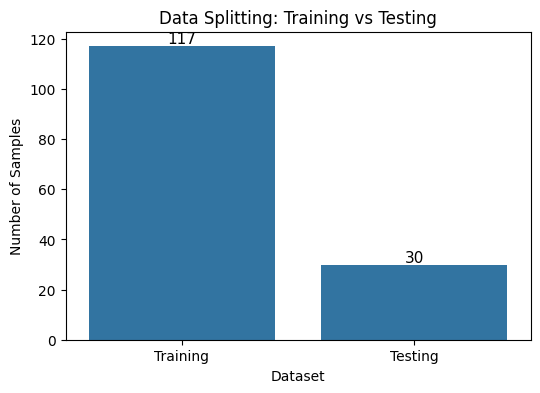

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah data
split_counts = {
    "Training": len(X_train),
    "Testing": len(X_test)
}

# Buat visualisasi
plt.figure(figsize=(6,4))
sns.barplot(
    x=list(split_counts.keys()),
    y=list(split_counts.values())
)

plt.title("Data Splitting: Training vs Testing")
plt.ylabel("Number of Samples")
plt.xlabel("Dataset")

for i, v in enumerate(split_counts.values()):
    plt.text(i, v + 1, str(v), ha='center', fontsize=11)

plt.show()

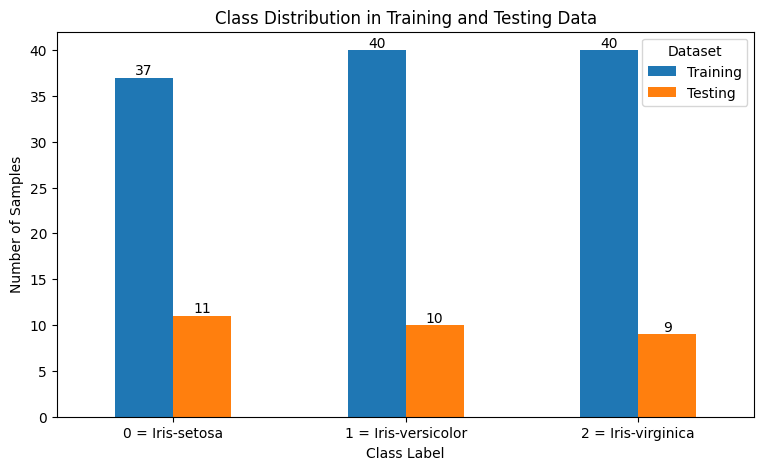

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Buat tabel distribusi kelas
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

class_dist = pd.DataFrame({
    "Training": train_counts,
    "Testing": test_counts
})

# Ubah label index jadi lebih jelas
class_labels = {
    0: "0 = Iris-setosa",
    1: "1 = Iris-versicolor",
    2: "2 = Iris-virginica"
}

class_dist.index = [class_labels[i] for i in class_dist.index]

# Plot
ax = class_dist.plot(kind="bar", figsize=(9,5))

plt.title("Class Distribution in Training and Testing Data")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Dataset")

# Tambahkan angka di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

Cek Distribusi Data Training dan Testing

In [21]:
print("Distribusi kelas pada training data:")
print(y_train.value_counts())

print("\nDistribusi kelas pada testing data:")
print(y_test.value_counts())

Distribusi kelas pada training data:
species_encoded
2    40
1    40
0    37
Name: count, dtype: int64

Distribusi kelas pada testing data:
species_encoded
0    11
1    10
2     9
Name: count, dtype: int64


# Modeling dengan KNN

Training Model KNN

In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

Prediksi Data Testing

In [23]:
y_pred = knn.predict(X_test)

print("Contoh hasil prediksi:")
print(y_pred[:10])

Contoh hasil prediksi:
[2 1 2 0 1 0 1 0 2 0]


Bandingkan Prediksi dan Data Asli

In [24]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
127,2,2
53,1,1
140,2,2
19,0,0
106,2,1
12,0,0
78,1,1
31,0,0
83,1,2
9,0,0


Visualisasi 

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

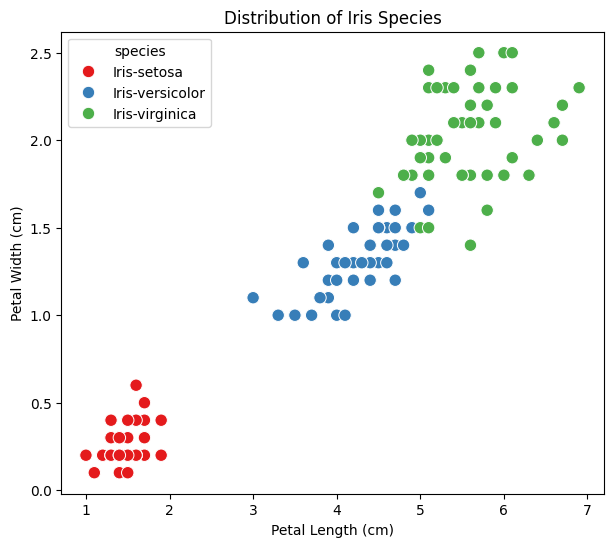

In [26]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    data=df_clean,
    x="petallengthcm",
    y="petalwidthcm",
    hue="species",
    palette="Set1",
    s=80
)

plt.title("Distribution of Iris Species")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.show()

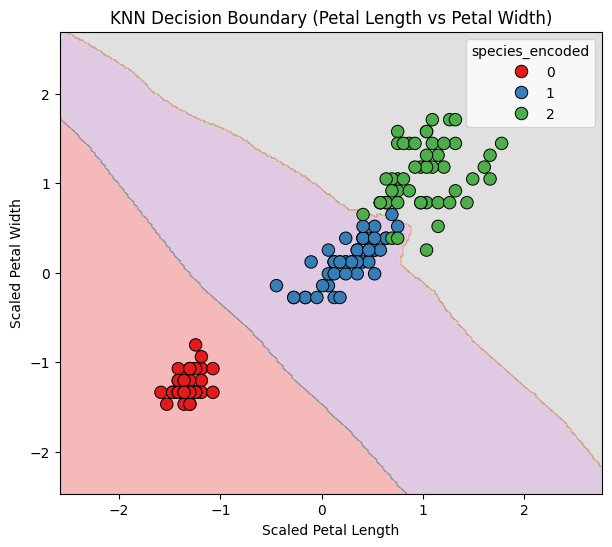

In [27]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# PILIH FITUR UNTUK VISUALISASI

X_vis = df_clean[["petallengthcm","petalwidthcm"]]
y_vis = df_clean["species_encoded"]

# SCALING

scaler = StandardScaler()
X_vis_scaled = scaler.fit_transform(X_vis)

# TRAIN KNN

knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis_scaled, y_vis)


# MEMBUAT GRID UNTUK DECISION BOUNDARY

x_min, x_max = X_vis_scaled[:,0].min()-1, X_vis_scaled[:,0].max()+1
y_min, y_max = X_vis_scaled[:,1].min()-1, X_vis_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


# VISUALISASI

plt.figure(figsize=(7,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="Set1")

sns.scatterplot(
    x=X_vis_scaled[:,0],
    y=X_vis_scaled[:,1],
    hue=y_vis,
    palette="Set1",
    s=80,
    edgecolor="black"
)

plt.title("KNN Decision Boundary (Petal Length vs Petal Width)")
plt.xlabel("Scaled Petal Length")
plt.ylabel("Scaled Petal Width")

plt.show()

In [28]:
from sklearn.metrics import accuracy_score

y_pred = knn.predict(X_test)

print("Jumlah data test :", len(y_test))
print("Akurasi          :", accuracy_score(y_test, y_pred))
print("Jumlah benar     :", (y_test == y_pred).sum())
print("Jumlah salah     :", (y_test != y_pred).sum())
print("Index salah      :", (y_test != y_pred))

Jumlah data test : 30
Akurasi          : 0.9333333333333333
Jumlah benar     : 28
Jumlah salah     : 2
Index salah      : 127    False
53     False
140    False
19     False
106     True
12     False
78     False
31     False
83      True
9      False
26     False
98     False
146    False
69     False
136    False
68     False
18     False
71     False
126    False
30     False
29     False
107    False
38     False
120    False
57     False
22     False
66     False
135    False
84     False
11     False
Name: species_encoded, dtype: bool


Data yang salah diprediksi 

In [29]:
import pandas as pd

# 1. Buat kondisi (mask) di mana nilai aktual tidak sama dengan prediksi
salah_prediksi_mask = y_test != y_pred

# 2. Ambil data asli dari df_clean berdasarkan indeks data yang salah
# (Indeks dari y_test tetap sama dengan indeks di df_clean saat di-split)
data_salah = df_clean.loc[y_test[salah_prediksi_mask].index].copy()

# 3. Tambahkan kolom Aktual dan Prediksi agar mudah dibaca (ubah kembali ke bentuk teks)
data_salah['Label_Aktual'] = encoder.inverse_transform(y_test[salah_prediksi_mask])
data_salah['Label_Prediksi'] = encoder.inverse_transform(y_pred[salah_prediksi_mask])

# 4. Tampilkan data yang salah prediksi
print(f"Total data salah prediksi: {len(data_salah)} baris\n")
display(data_salah)

Total data salah prediksi: 2 baris



,sepallengthcm,sepalwidthcm,petallengthcm,petalwidthcm,species,species_encoded,Label_Aktual,Label_Prediksi
106,4.9,2.5,4.5,1.7,Iris-virginica,2,Iris-virginica,Iris-versicolor
83,6.0,2.7,5.1,1.6,Iris-versicolor,1,Iris-versicolor,Iris-virginica


# Model Evaluation

In [30]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

Accuracy Model

In [31]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Model KNN :", round(accuracy,4))

Accuracy Model KNN : 0.9333


Classification Report

In [32]:
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.89      0.89      0.89         9

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



Confusion Matrix

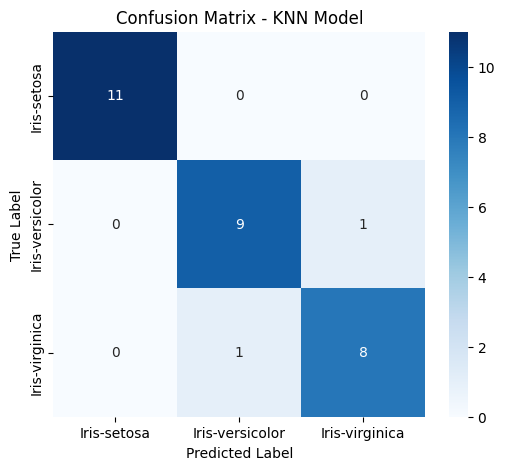

In [33]:
from sklearn.metrics import confusion_matrix

# hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - KNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# Hyperparameter Optimization

Metode Elbow

In [34]:
from sklearn.neighbors import KNeighborsClassifier

error_rate = []

k_range = range(1, 21)

for k in k_range:
    
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    pred_k = knn.predict(X_test)
    
    error = np.mean(pred_k != y_test)
    
    error_rate.append(error)

Visualisasi

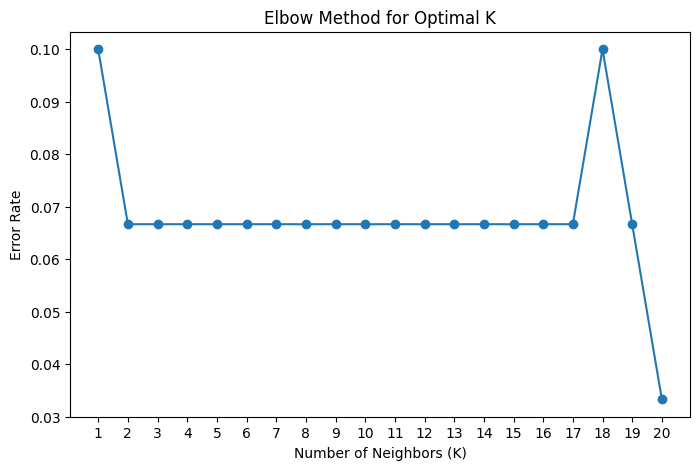

In [35]:
plt.figure(figsize=(8,5))

plt.plot(k_range, error_rate, marker='o')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error Rate")

plt.xticks(k_range)

plt.show()

Titik dimana error mulai stabil merupakan nilai K optimal.

In [36]:
# MODEL FROM ELBOW METHOD

knn_elbow = KNeighborsClassifier(n_neighbors=5)

knn_elbow.fit(X_train, y_train)

pred_elbow = knn_elbow.predict(X_test)

acc_elbow = accuracy_score(y_test, pred_elbow)

print("Accuracy (Elbow Method):", round(acc_elbow,4))

Accuracy (Elbow Method): 0.9333


Grid Search

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    
    "n_neighbors": list(range(1,21)),
    
    "weights": ["uniform","distance"],
    
    "metric": ["euclidean","manhattan","minkowski"]
}

grid = GridSearchCV(
    
    KNeighborsClassifier(),
    
    param_grid,
    
    cv=5,
    
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 6, 'weights': 'distance'}
Best Accuracy: 0.9829710144927537


In [38]:
# MODEL FROM GRID SEARCH

knn_grid = grid.best_estimator_

pred_grid = knn_grid.predict(X_test)

acc_grid = accuracy_score(y_test, pred_grid)

print("Accuracy (Grid Search):", round(acc_grid,4))

Accuracy (Grid Search): 0.9333


Optuna

In [39]:
!pip install optuna

In [40]:
import optuna

def objective(trial):
    
    n_neighbors = trial.suggest_int("n_neighbors",1,20)
    
    weights = trial.suggest_categorical("weights",["uniform","distance"])
    
    metric = trial.suggest_categorical("metric",["euclidean","manhattan"])
    
    
    model = KNeighborsClassifier(
        
        n_neighbors=n_neighbors,
        
        weights=weights,
        
        metric=metric
    )
    
    model.fit(X_train,y_train)
    
    preds = model.predict(X_test)
    
    return accuracy_score(y_test,preds)


study = optuna.create_study(direction="maximize")

study.optimize(objective,n_trials=50)

print("Best Parameters:", study.best_params)

[I 2026-04-13 03:47:14,179] A new study created in memory with name: no-name-5f68367c-497d-4138-bec4-f4023fd72d47
[I 2026-04-13 03:47:14,191] Trial 0 finished with value: 0.9333333333333333 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 0 with value: 0.9333333333333333.
[I 2026-04-13 03:47:14,199] Trial 1 finished with value: 0.9333333333333333 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 0 with value: 0.9333333333333333.
[I 2026-04-13 03:47:14,208] Trial 2 finished with value: 0.9333333333333333 and parameters: {'n_neighbors': 14, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 0.9333333333333333.
[I 2026-04-13 03:47:14,215] Trial 3 finished with value: 0.9333333333333333 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 0 with value: 0.9333333333333333.
[I 2026-04-13 03:47:14,222] Trial 4 finished with value: 0.866

Best Parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'manhattan'}


In [41]:
best_params = study.best_params

knn_optuna = KNeighborsClassifier(
    n_neighbors=best_params["n_neighbors"],
    weights=best_params["weights"],
    metric=best_params["metric"]
)

knn_optuna.fit(X_train, y_train)

pred_optuna = knn_optuna.predict(X_test)

acc_optuna = accuracy_score(y_test, pred_optuna)

print("Accuracy (Optuna):", round(acc_optuna,4))

Accuracy (Optuna): 0.9333


In [42]:
# COMPARE ALL MODELS

results = pd.DataFrame({
    
    "Method": ["Elbow Method","Grid Search","Optuna"],
    
    "Accuracy": [acc_elbow, acc_grid, acc_optuna]
})

print(results)

         Method  Accuracy
0  Elbow Method  0.933333
1   Grid Search  0.933333
2        Optuna  0.933333


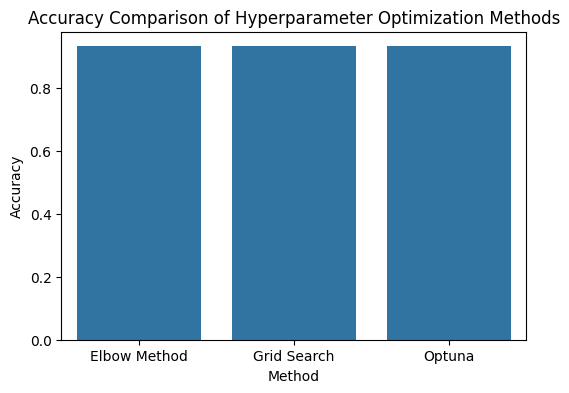

In [43]:
# VISUALIZATION OF MODEL COMPARISON

plt.figure(figsize=(6,4))

sns.barplot(
    x="Method",
    y="Accuracy",
    data=results
)

plt.title("Accuracy Comparison of Hyperparameter Optimization Methods")

plt.ylabel("Accuracy")

plt.show()

# Final Model Evaluation

Hyperparameter Terbaik

In [44]:
best_params = study.best_params

print("Best Hyperparameters (Optuna):")
print(best_params)

Best Hyperparameters (Optuna):
{'n_neighbors': 6, 'weights': 'distance', 'metric': 'manhattan'}


Prediksi Model Final

In [45]:
final_knn = KNeighborsClassifier(
    n_neighbors=best_params["n_neighbors"],
    weights=best_params["weights"],
    metric=best_params["metric"]
)

# training model final
final_knn.fit(X_train, y_train)

# prediksi data test
y_pred_final = final_knn.predict(X_test)

print("Contoh Prediksi:")
print(y_pred_final[:10])

Contoh Prediksi:
[2 1 2 0 1 0 1 0 2 0]


Accuracy

In [46]:
from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(y_test, y_pred_final)

print("Final Model Accuracy:", round(final_accuracy,4))

Final Model Accuracy: 0.9333


Classification Report

In [47]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_final,
    target_names=encoder.classes_
))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.89      0.89      0.89         9

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



Visualisasi Confusion Matrix

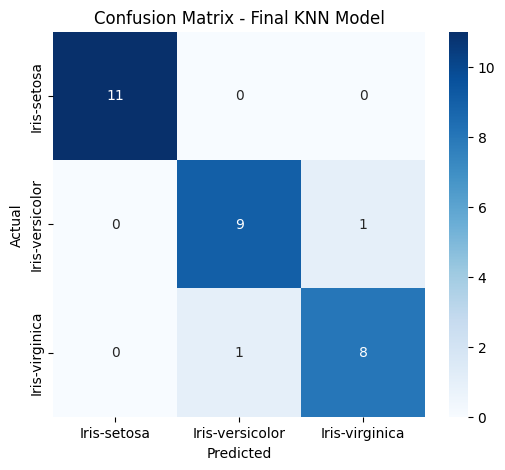

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - Final KNN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Visualisasi Perbandingan Model

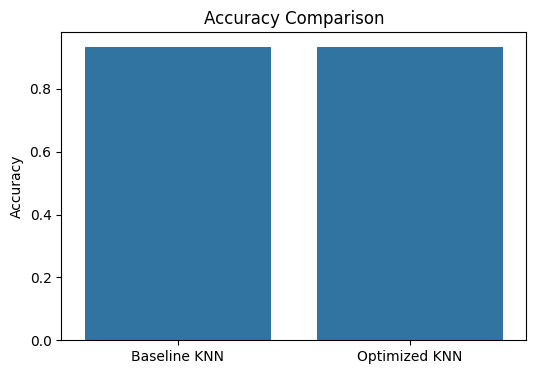

In [49]:
models = ["Baseline KNN","Optimized KNN"]
scores = [accuracy, final_accuracy]

plt.figure(figsize=(6,4))

sns.barplot(x=models, y=scores)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()